# Ridge & Lasso Regression

## Student Lifestyle vs Exam Performance

### Step 1: Import Libraries

In [67]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### Step 2: Load Dataset

In [68]:
df = pd.read_csv(r"D:\4th Semester\Machine Learning by Sir  Abdul Aziz\Student_performance_data _.csv")
df.head(7)

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
5,1006,18,0,0,1,8.191219,0,0,1,1,0,0,0,3.084184,1.0
6,1007,15,0,1,1,15.601680,10,0,3,0,1,0,0,2.748237,2.0


### Step 3: Data Preprocessing & EDA

In [69]:
# Information about Data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [70]:
# Rows & Columns
df.shape

(2392, 15)

In [71]:
# Statistical Description
df.describe()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


In [72]:
# Check Missing Values
df.isnull().sum()         # No Missing value

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [73]:
# Check Duplication
df.duplicated().sum()

np.int64(0)

### Step 4: Encoding of Dataset

In [74]:
# No Encoding Needed

### Step 5: Normalization

In [75]:
df.drop(columns=['StudentID'],inplace=True)        # Drop Student ID column because of its no use.
df.drop(columns=['GradeClass'],inplace=True)       # Drop GradeClass column because we are solving regression that's target variable is GPA.

In [76]:
df.head(2)

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915


In [77]:
# Balance the Dataset
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
df['Age'] = ss.fit_transform(df[['Age']])
df['StudyTimeWeekly'] = ss.fit_transform(df[['StudyTimeWeekly']])
df['Absences'] = ss.fit_transform(df[['Absences']])
df['GPA'] = ss.fit_transform(df[['GPA']])

In [78]:
df.head(8)

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA
0,0.472919,1,0,2,1.780336,-0.890822,1,2,0,0,1,0,1.118086
1,1.362944,0,0,1,0.997376,-1.717694,0,1,0,0,0,0,1.242374
2,-1.307132,0,2,3,-0.984045,1.353542,0,2,0,0,0,0,-1.960277
3,0.472919,1,0,3,0.045445,-0.063951,0,3,1,0,0,0,0.161790
4,0.472919,1,0,2,-0.902311,0.290422,1,3,0,0,0,0,-0.675573
5,1.362944,0,0,1,-0.279704,-1.717694,0,1,1,0,0,0,1.287479
6,-1.307132,0,1,1,1.031513,-0.536449,0,3,0,1,0,0,0.920310
7,-1.307132,1,1,4,1.000161,0.881045,1,1,1,0,0,0,-0.596792


### Step 6: Check Linearity of data

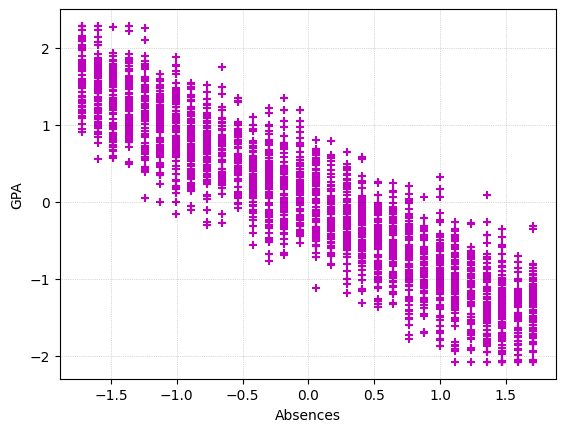

In [79]:
plt.scatter(df['Absences'],df['GPA'], marker='+',color='m')
plt.grid(color='k', linestyle=':', linewidth=0.5, alpha=0.3)
plt.xlabel('Absences')
plt.ylabel('GPA')
plt.show()

### Step 7: Check Correlation

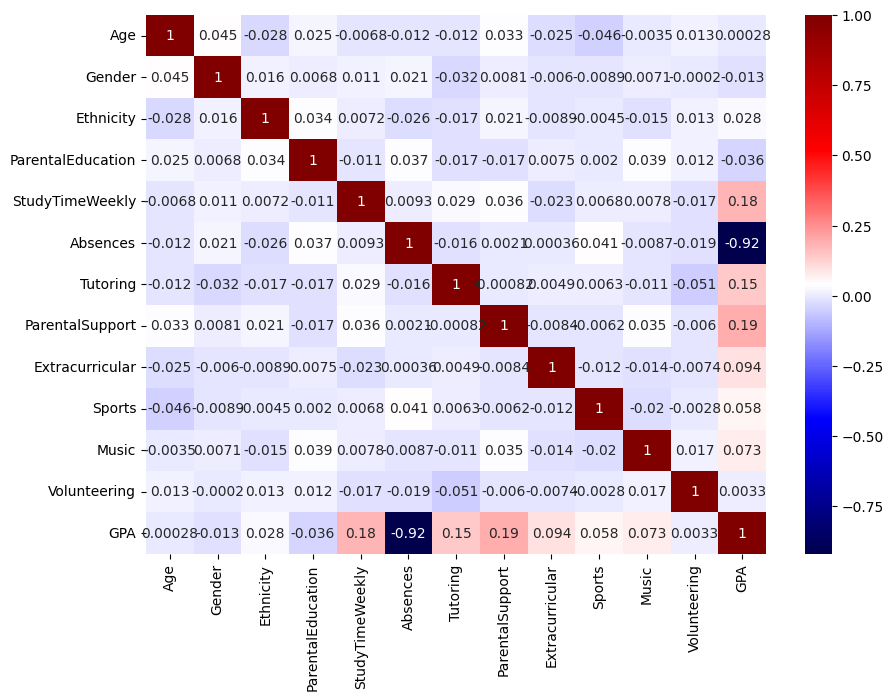

In [80]:
# Checking relation between Columns
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(),annot=True,cmap='seismic')
plt.show()

### Step 8: Splitting of Data into Training & Testing

In [82]:
df.columns

Index(['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly',
       'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports',
       'Music', 'Volunteering', 'GPA'],
      dtype='str')

In [83]:
X = df[['StudyTimeWeekly','Absences','Tutoring','ParentalSupport','Extracurricular']]
y = df['GPA']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Step 9: Ridge Model ( used to reduce risk of Overfitting by reducng coefficients )

In [116]:
# Apply Model
from sklearn.linear_model import Ridge
r =Ridge(alpha=10)
r.fit(X_train,y_train)
r.score(X_test,y_test)*100

93.88710126467194

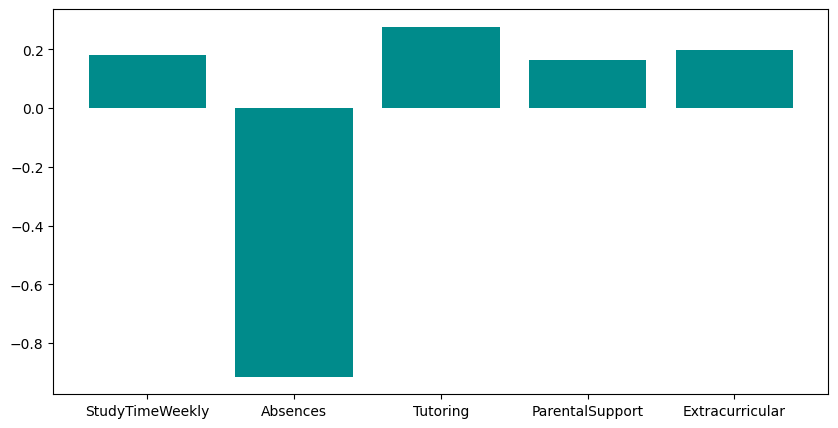

In [117]:
# Graphical Representation
plt.figure(figsize=(10,5))
plt.bar(X.columns,r.coef_,color='Darkcyan')
plt.show()

### Step 11: Lasso Regression ( used for Feature Selection )

In [118]:
# Apply Model
from sklearn.linear_model import Lasso
l =Lasso(alpha=0.5)
l.fit(X_train,y_train)
l.score(X_test,y_test)*100

59.622934494374924

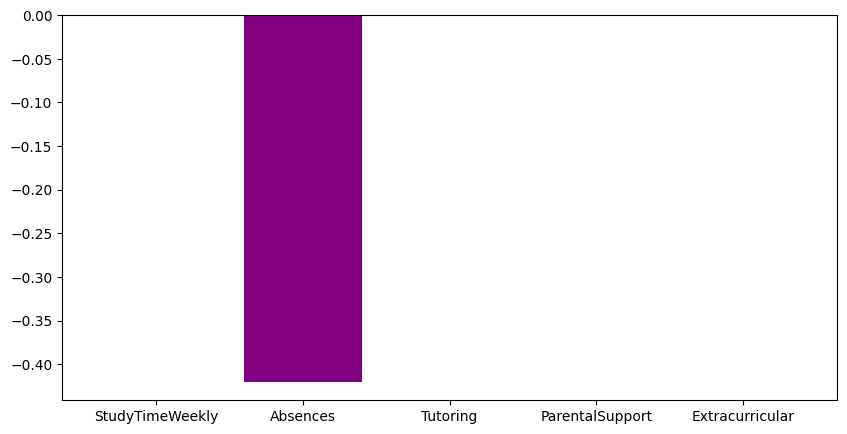

In [106]:
# Graphical Representation
plt.figure(figsize=(10,5))
plt.bar(X.columns,l.coef_,color='purple')
plt.show()

###  Step 12: Comparison

In [109]:
pd.DataFrame({"Features":X.columns,"Ridge":r.coef_,"Lasso":l.coef_})

,Features,Ridge,Lasso
0,StudyTimeWeekly,0.181913,0.000000
1,Absences,-0.915002,-0.420437
2,Tutoring,0.277085,0.000000
3,ParentalSupport,0.162696,0.000000
4,Extracurricular,0.199685,0.000000


## Congratulations, I Completed Ridge & lasso Regression/Regularization !!!!!!!!!